#### imports and preliminaries

In [1]:
from pathlib import Path
import numpy as np
import h5py
from scipy.io import loadmat

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from utils.lot_functions import *

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning, module="skimage")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*min_size.*")

#### import PyTransKit

In [2]:
from pytranskit.optrans.continuous.discretelot import DiscreteLOT

#### select data and parameters

In [3]:
dataname = "liver"
# dataname = "thyroid"

## ---------------------
Nms = 500
I0_seed = 21
I1_seed = 2

# Base folder
BASE = Path.cwd()

In [4]:
dLOT=DiscreteLOT()

def LOT_Embedding(X0, a0, X1_list, a1_list):
    n_cores = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count())) # os.cpu_count() or 1
    print(f"Using {n_cores} CPU cores ...\n")

    dLOT.fit(X0, a0)
    def solve_one(i):
        return dLOT.transform(X1_list[i], a1_list[i])

    results = Parallel(n_jobs=n_cores)(delayed(solve_one)(i) for i in tqdm(range(len(X1_list)), desc="LOT Embedding"))
    X1_hat_list, a1_hat_list = zip(*results)
    return list(X1_hat_list), a1_hat_list[-1]

#### load data and reference

In [5]:
ref_file = BASE / "data" / "LOT_reference.mat"
mat = loadmat(ref_file)
I0 = mat['I0']

In [6]:
datafile = BASE / "data" / f"{dataname}" / "IMG_data.mat"
with h5py.File(datafile, "r") as f:
    dset = f["xx"]              # actual shape: (N, Y, X)
    N, Y, X = dset.shape
    imgs = np.zeros((N, X, Y), dtype=np.float32)
    for i in range(N):
        img = dset[i, :, :].astype(np.float32)   # (Y, X)
        s = np.sum(img)
        if s != 0:
            img /= s
        imgs[i, :, :] = img.T                    # → (X, Y)

    # load labels
    class_label = np.array(f["label"]).squeeze()
    patient_label = np.array(f["pat_label"]).squeeze()


#### particle approximation

In [7]:
X0, a0 = img2pts_Lloyd_v2(I0, Nms, seed=I0_seed)
X1_list, a1_list = particleApproximation(imgs, Nms, seed=I1_seed)


Using 40 CPU cores ...



Particle Approximation: 100%|██████████| 2966/2966 [00:11<00:00, 265.24it/s]


#### discrete LOT embedding

In [8]:
# LOT Embedding
X1_hat_list, p_w = LOT_Embedding(X0, a0, X1_list, a1_list)

u = []
for a in range(len(X1_hat_list)):
    ua = X1_hat_list[a].reshape(-1, 1, order='F') 
    u.append(ua)
u = np.concatenate(u, axis=1).T

Using 40 CPU cores ...



LOT Embedding: 100%|██████████| 2966/2966 [06:46<00:00,  7.30it/s]


#### organize and training testing split

In [9]:
data={}
data["lot"] = {
        "u": np.array(u),
        "p_w": np.array(p_w).squeeze(),
        "label": np.array(class_label).squeeze(),
        "pat_id": np.array(patient_label).squeeze(),
        }

stratify_label = data["lot"]["label"]
all_indices = np.arange(len(stratify_label))

train_idx, test_idx = train_test_split(all_indices, test_size=0.5, stratify=stratify_label, random_state=42)

In [10]:
X_train = data["lot"]["u"][train_idx]  
X_test  = data["lot"]["u"][test_idx]  

y_train = data["lot"]["label"][train_idx] 
y_test = data["lot"]["label"][test_idx]  

pat_id_tr = data["lot"]["pat_id"][train_idx] 
pat_id_te = data["lot"]["pat_id"][test_idx] 

#### PCA in LOT space 

In [11]:
pca=PCA(n_components=10)
proj_tr = pca.fit_transform(X_train) 
proj_te = pca.transform(X_test)

b_hat = pca.components_   

Psimean_ref = np.mean(X_train, axis=0)

#### axis computation (inverse transform)

In [12]:
M = 300; N = 300
n_cores = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count())) # os.cpu_count() or 1
print(f"Using {n_cores} CPU cores ...\n")

def compute_block(i):
    std_i = np.sqrt(pca.explained_variance_[i])
    lam = np.linspace(-5 * std_i, 5 * std_i, 7)
    imgs = [visualize_LOT(Psimean_ref + l * b_hat[i,:], data["lot"]["p_w"], 300, 300, 2)[M//5:-M//5, M//5:-M//5] for l in lam]
    return np.hstack(imgs)

blocks = Parallel(n_jobs=n_cores)(
    delayed(compute_block)(i) for i in tqdm(range(10), desc="Feature blocks")
)

Using 40 CPU cores ...



Feature blocks: 100%|██████████| 10/10 [00:00<00:00, 13893.02it/s]


#### visualization 1

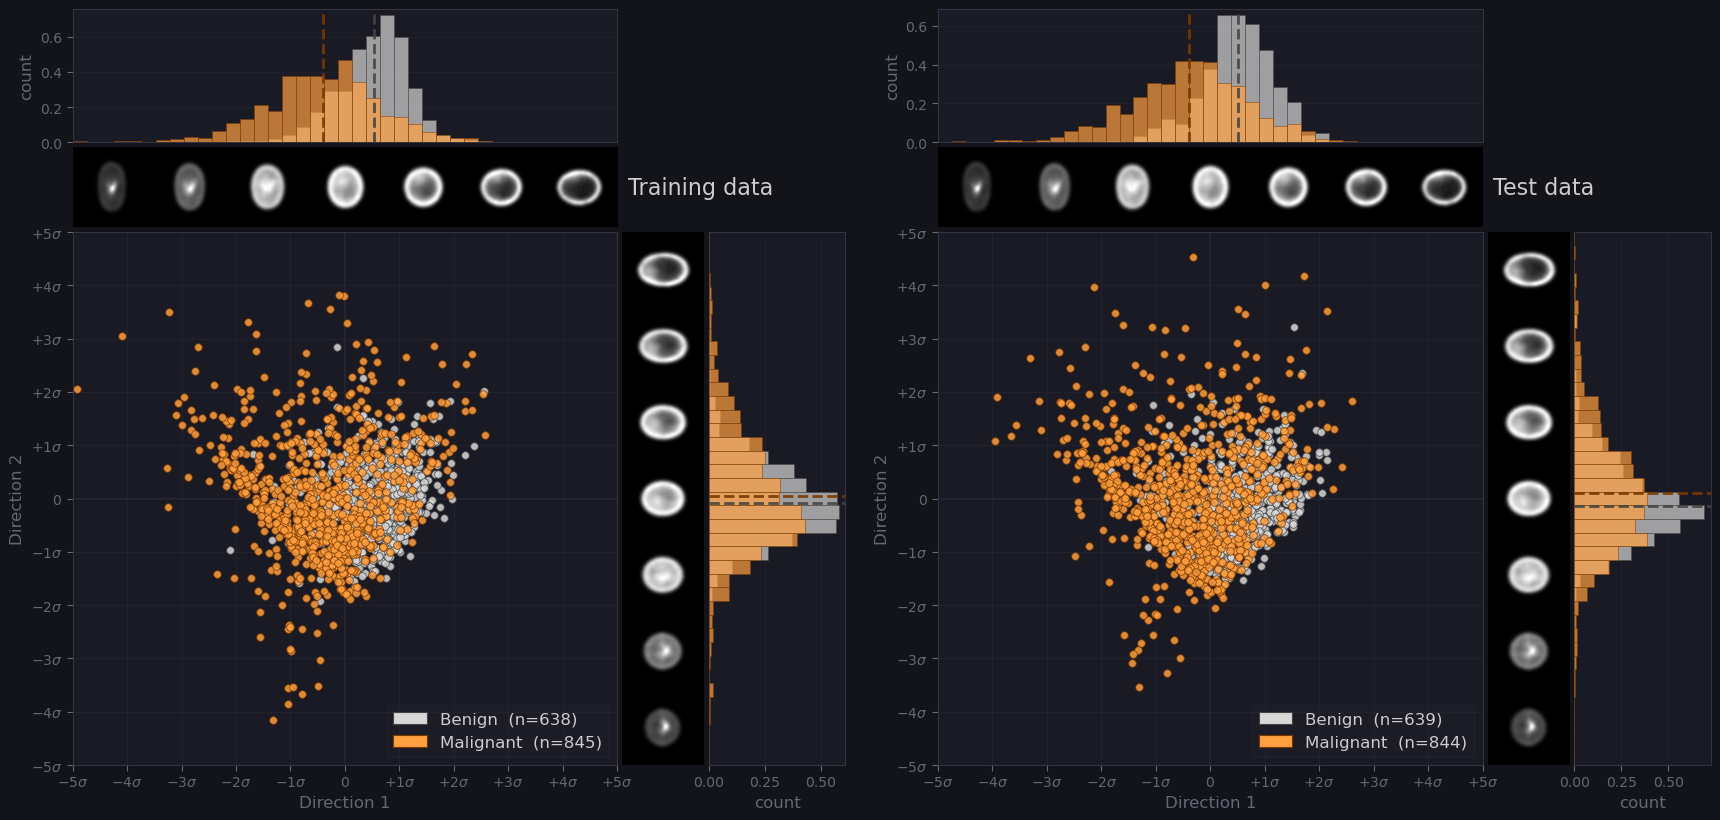

In [13]:
fig = make_figure(proj_tr, y_train, pat_id_tr, proj_te, y_test, pat_id_te, title_tr='Training data', title_te='Test data', show_contours=True, n_std=0.5, point_size=30, point_alpha=0.85, blocks=blocks)


#### visualization 2

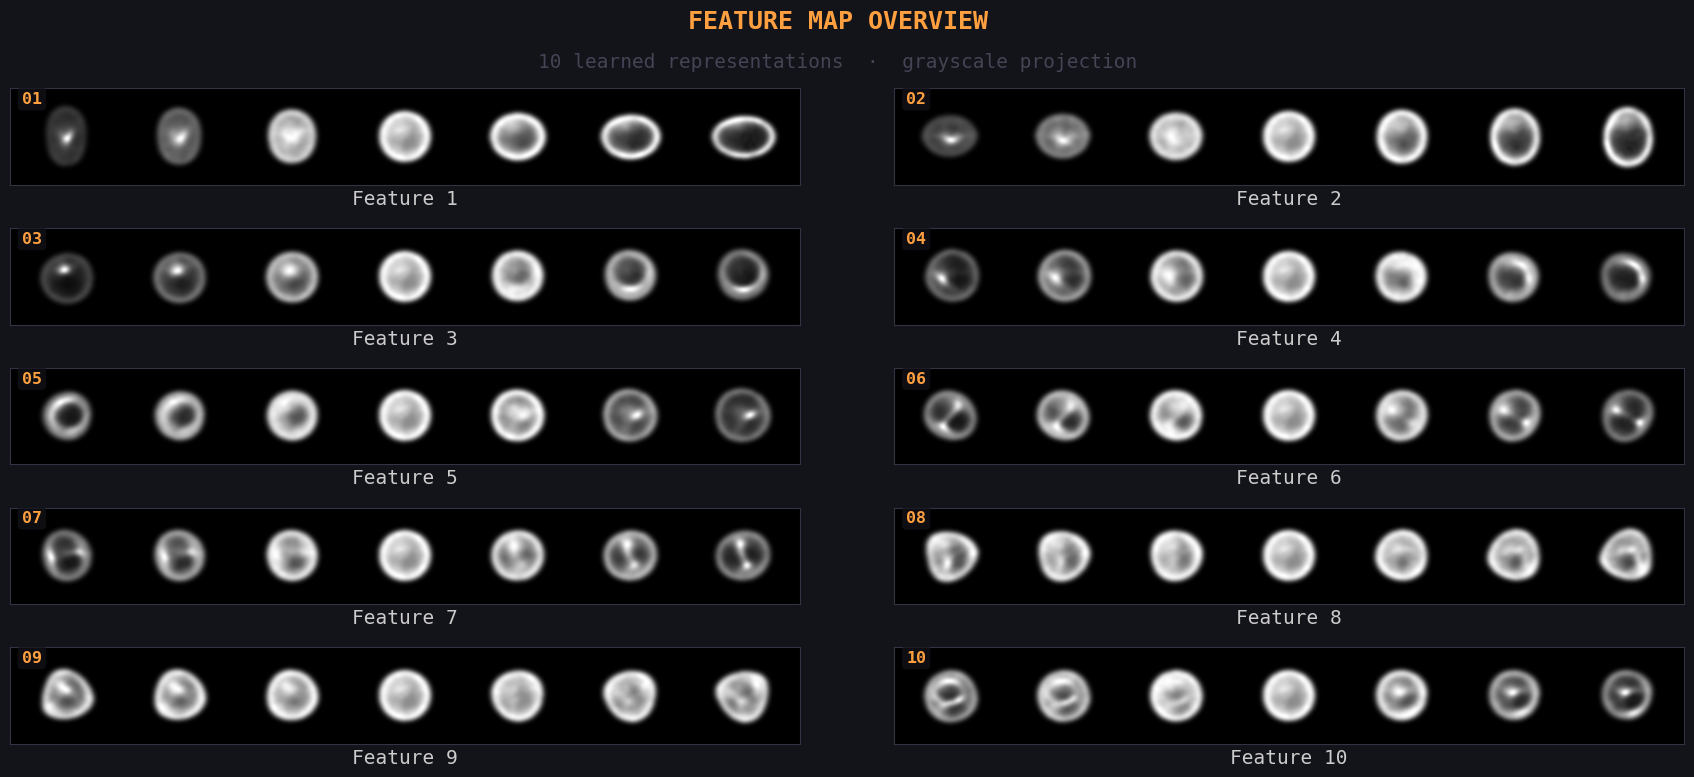

In [14]:
fig = plot_feature_maps(blocks)